# **Installing Dependencies**

In [19]:
# Check and install torch + torchvision + torchaudio
try:
    import torch
    import torchvision
    import torchaudio
    print("Torch, torchvision, and torchaudio already installed")
except ImportError:
    !pip install timm torch torchvision torchaudio tqdm scikit-learn

# Check and install matplotlib + opencv
try:
    import matplotlib
    import cv2
    print("Matplotlib and OpenCV already installed")
except ImportError:
    !pip install matplotlib opencv-python

Torch, torchvision, and torchaudio already installed
Matplotlib and OpenCV already installed


# **Initializing Libraries and Imports**

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import timm
import pandas as pd
import os
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import random

# **Loading Dataset from Google Colab**

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
root = "/content/drive/MyDrive/Bird_Species_Detection"
!ls {root}

attributes	    files		    manually_selected_images
bounding_boxes.txt  image_class_labels.txt  parts
check_images	    images		    README
classes.txt	    images.txt		    train_test_split.txt


In [23]:
images_df = pd.read_csv(f"{root}/images.txt", sep=" ", names=["img_id", "path"])
labels_df = pd.read_csv(f"{root}/image_class_labels.txt", sep=" ", names=["img_id", "label"])
bbox_df   = pd.read_csv(f"{root}/bounding_boxes.txt", sep=" ", names=["img_id", "x", "y", "w", "h"])
split_df  = pd.read_csv(f"{root}/train_test_split.txt", sep=" ", names=["img_id", "is_train"])

In [24]:
data_df = images_df.merge(labels_df, on="img_id")
data_df = data_df.merge(bbox_df, on="img_id")
data_df = data_df.merge(split_df, on="img_id")

In [25]:
data_df

,img_id,path,label,x,y,w,h,is_train
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,60.0,27.0,325.0,304.0,0
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,139.0,30.0,153.0,264.0,1
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,14.0,112.0,388.0,186.0,0
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,112.0,90.0,255.0,242.0,1
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,70.0,50.0,134.0,303.0,1
...,...,...,...,...,...,...,...,...
11783,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,89.0,95.0,354.0,250.0,1
11784,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,157.0,62.0,184.0,219.0,0
11785,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,190.0,102.0,198.0,202.0,0
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,3.0,20.0,408.0,307.0,1


# **Images converted to Tensors**

In [26]:
class BirdDataset(Dataset):
    def __init__(self, dataframe, root, transforms=None):
        self.df = dataframe
        self.root = os.path.join(root, "images")
        self.transforms = transforms

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row["path"])

        # image read
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.tensor(img).permute(2,0,1) / 255.0

        # bounding box [x_min, y_min, x_max, y_max]
        x_min = row["x"]
        y_min = row["y"]
        x_max = row["x"] + row["w"]
        y_max = row["y"] + row["h"]

        boxes = torch.tensor([[x_min, y_min, x_max, y_max]], dtype=torch.float32)
        labels = torch.tensor([row["label"]], dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}

        return img, target

    def __len__(self):
        return len(self.df)

In [27]:
train_df = data_df[data_df["is_train"] == 1].reset_index(drop=True)
test_df  = data_df[data_df["is_train"] == 0].reset_index(drop=True)

train_dataset = BirdDataset(train_df, root)
test_dataset  = BirdDataset(test_df, root)

In [28]:
test_df

,img_id,path,label,x,y,w,h,is_train
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,60.0,27.0,325.0,304.0,0
1,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,14.0,112.0,388.0,186.0,0
2,6,001.Black_footed_Albatross/Black_Footed_Albatr...,1,33.0,53.0,251.0,395.0,0
3,10,001.Black_footed_Albatross/Black_Footed_Albatr...,1,27.0,4.0,199.0,201.0,0
4,12,001.Black_footed_Albatross/Black_Footed_Albatr...,1,47.0,21.0,179.0,249.0,0
...,...,...,...,...,...,...,...,...
5789,11780,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,44.0,114.0,269.0,230.0,0
5790,11783,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,96.0,71.0,243.0,216.0,0
5791,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,157.0,62.0,184.0,219.0,0
5792,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,190.0,102.0,198.0,202.0,0


In [29]:
train_df

,img_id,path,label,x,y,w,h,is_train
0,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,139.0,30.0,153.0,264.0,1
1,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,112.0,90.0,255.0,242.0,1
2,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,70.0,50.0,134.0,303.0,1
3,7,001.Black_footed_Albatross/Black_Footed_Albatr...,1,7.0,75.0,420.0,262.0,1
4,8,001.Black_footed_Albatross/Black_Footed_Albatr...,1,78.0,86.0,333.0,158.0,1
...,...,...,...,...,...,...,...,...
5989,11778,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,35.0,115.0,290.0,197.0,1
5990,11781,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,41.0,33.0,379.0,426.0,1
5991,11782,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,140.0,125.0,144.0,172.0,1
5992,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,200,89.0,95.0,354.0,250.0,1


# **Validation Proof**

Image shape: torch.Size([3, 500, 447])
Target: {'boxes': tensor([[109., 110., 401., 425.]]), 'labels': tensor([12])}


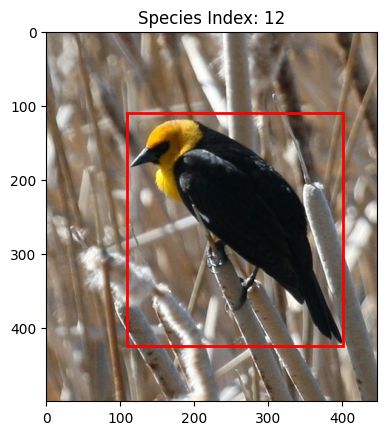

In [30]:
# Pick a random sample from the training dataset
idx = random.randint(0, len(train_dataset) - 1)
img, target = train_dataset[idx]

print("Image shape:", img.shape)   # Should be [3, H, W]
print("Target:", target)

# Convert image back to numpy for visualization
img_np = img.permute(1, 2, 0).numpy()

# Plot with bounding box
plt.imshow(img_np)
x_min, y_min, x_max, y_max = target["boxes"][0]
plt.gca().add_patch(plt.Rectangle(
    (x_min, y_min), x_max - x_min, y_max - y_min,
    fill=False, color='red', linewidth=2
))
plt.title(f"Species Index: {target['labels'].item()}")
plt.show()

# **ResNet18**

In [31]:
import torchvision.transforms as T

# Define transforms
train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),       # resize all images to 224x224
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])   # Imagenet normalization
])

test_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [32]:
class BirdDataset(Dataset):
    def __init__(self, dataframe, root, transforms=None):
        self.df = dataframe
        self.root = os.path.join(root, "images")
        self.transforms = transforms

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row["path"])

        # read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(img)   # apply transforms (resize, normalize)

        labels = torch.tensor(row["label"] - 1, dtype=torch.long)  # make labels 0-indexed
        return img, labels   # ✅ return directly img + label for classification

    def __len__(self):
        return len(self.df)

In [33]:
train_dataset = BirdDataset(train_df, root, transforms=train_transforms)
test_dataset  = BirdDataset(test_df, root, transforms=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [34]:
# -----------------------------
# ✅ Save & Load Checkpoints
# -----------------------------
def save_checkpoint(epoch, model, optimizer, filename="checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    torch.save(checkpoint, filename)
    print(f"💾 Checkpoint saved: {filename}")

def load_checkpoint(model, optimizer, filename="checkpoint.pth"):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"🔄 Resumed from epoch {start_epoch}")
    return start_epoch

# -----------------------------
# ⚙️ Device Setup
# -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

# -----------------------------
# 🐦 Model Setup
# -----------------------------
num_classes = len(train_df['label'].unique())  # Adjust label column name if needed

model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

# (Optional) Freeze early layers for faster fine-tuning
for name, param in model.named_parameters():
    if "fc" not in name:  # only train the final layer
        param.requires_grad = False

model = model.to(device)

# -----------------------------
# 🧮 Loss & Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# -----------------------------
# 🔁 Training Loop
# -----------------------------
start_epoch = 0
epochs = 100

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / (len(pbar)): .4f}")

    avg_loss = running_loss / len(train_loader)
    print(f"\n✅ Epoch [{epoch+1}/{epochs}] completed | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint every 2 epochs
    if (epoch + 1) % 2 == 0:
        save_checkpoint(epoch, model, optimizer)

print("🎉 Training completed successfully!")

🔥 Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/100:   2%|▏         | 4/188 [01:42<1:18:52, 25.72s/batch, loss=0.1165]


KeyboardInterrupt: 

# **Confusion Matrix (ResNet18)**

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Bird Species Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
class_names = list(train_df['label'].unique())  # or the actual species names list

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Bird Species Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
class_names = [str(c) for c in sorted(train_df['label'].unique())]

print("📈 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

In [ ]:
test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ✅ Use same test transforms
predict_transforms = test_transforms

# Example usage
class_names = sorted(train_df['label'].unique())  # or actual species names if available
image_path = "/content/drive/MyDrive/Bird_Species_Detection/manually_selected_images/0011.jpg"

predicted = predict_image(image_path, model, class_names)

def predict_image(img_path, model, class_names):
    model.eval()
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = predict_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(inp)
        _, pred = torch.max(output, 1)

    pred_idx = pred.item()
    pred_class = class_names[pred_idx]
    print(f"🦜 Predicted Bird Species: {pred_class}")
    return pred_class